In [1]:
import torch
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# Uni boilerplate

In [2]:
MOCK_RUN = False
colours_list = [
    "red", "green", "blue",
    "yellow", "magenta",
    "cyan", "black",
    "orange", "purple",
    "pink", "lime", "navy",
    "teal", "brown", "gray",
    "olive", "maroon", "gold"
]

class parse_args:
  def __init__(self):
    self.n_seeds = 6
    self.n_evaluate_episodes = 5
    self.n_training_steps = 100000 if not MOCK_RUN else 100
    self.buffer_size = 10000 if not MOCK_RUN else 10
    self.init_steps = 10000 if not MOCK_RUN else 10
    self.target_update_freq = 50 if not MOCK_RUN else 1
    self.eval_freq = 1000 if not MOCK_RUN else 10
    self.gym_id = "LunarLander-v3"
    env = gym.make(self.gym_id)
    self.state_dim = env.observation_space.shape[0]
    self.batch_size = 128 
    self.hidden_dim = 128
    self.action_dim = env.action_space.n
    self.discount = 0.99
    self.lr = 7e-4
    self.cuda = True
    self.device = torch.device("cuda" if torch.cuda.is_available() and self.cuda else "cpu")

args = parse_args()
first_half_training_args = parse_args()
first_half_training_args.n_training_steps = first_half_training_args.n_training_steps // 2
second_half_training_args = parse_args()
second_half_training_args.n_training_steps = second_half_training_args.n_training_steps // 2
second_half_training_args.init_steps = 1

/home/jpniewski/studia/dnn/dnn4/.venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [3]:
def set_seed(seed):
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
  np.random.seed(seed)

def weight_init(model):
  torch.nn.init.orthogonal_(model.weight.data)
  model.bias.data.fill_(0.0)

Here we implement the replay buffer.
It has two methods: add one transition to the buffer and sample batch of transitions from the buffer.

In [4]:
class ReplayBuffer:
  def __init__(self, args):
    self.states = np.zeros((args.buffer_size, args.n_seeds, args.state_dim), dtype = np.float32)
    self.actions = np.zeros((args.buffer_size, args.n_seeds), dtype = np.int64)
    self.rewards = np.zeros((args.buffer_size, args.n_seeds), dtype = np.float32)
    self.next_states = np.zeros((args.buffer_size, args.n_seeds, args.state_dim), dtype = np.float32)
    self.terminals = np.zeros((args.buffer_size, args.n_seeds), dtype = np.int64)
    self.idx = 0
    self.current_size = 0
    self.args = args

  def add(self, state, action, reward, next_state, terminal):
    if self.current_size < self.args.buffer_size:
      self.current_size += 1
    self.states[self.idx, :, :] = state
    self.actions[self.idx, :] = action
    self.rewards[self.idx, :] = reward
    self.next_states[self.idx, :, :] = next_state
    self.terminals[self.idx, :] = terminal
    self.idx = (self.idx + 1) % self.args.buffer_size

  def sample(self):
    sample_idxs = np.random.permutation(self.current_size)[:self.args.batch_size]
    states = torch.from_numpy(self.states[sample_idxs]).to(self.args.device)
    actions = torch.from_numpy(self.actions[sample_idxs]).to(self.args.device)
    rewards = torch.from_numpy(self.rewards[sample_idxs]).to(self.args.device)
    next_states = torch.from_numpy(self.next_states[sample_idxs]).to(self.args.device)
    terminals = torch.from_numpy(self.terminals[sample_idxs]).to(self.args.device)

    return states, actions, rewards, next_states, terminals


Here we implement a simple Q network architecture with three layers and ReLU activations.

In [5]:
class QNetwork(torch.nn.Module):
  def __init__(self, args):
    super(QNetwork, self).__init__()
    self.layer_1 = torch.nn.Linear(args.state_dim, args.hidden_dim)
    self.layer_2 = torch.nn.Linear(args.hidden_dim, args.hidden_dim)
    self.layer_3 = torch.nn.Linear(args.hidden_dim, args.action_dim)
    self.relu = torch.nn.ReLU()

    self.layer_1.apply(weight_init)
    self.layer_2.apply(weight_init)
    self.layer_3.apply(weight_init)

  def forward(self, x):
    x = self.relu(self.layer_1(x))
    x = self.relu(self.layer_2(x))
    x = self.layer_3(x)

    return x

Here we provide code for DQN with random exploration.

In [6]:
TRAIN_SEED = 0
EVAL_SEED = 1

class DQN:
  def __init__(self, args):
    self.args = args
    self.discount = self.args.discount
    self.reset()
    self.annealing = False

  # Copying parameters of other DQN class by reference (for half epsion-greedy, half boltzmann task)
  def copy_reference(self, other):
    self.buffer = other.buffer
    self.q_net = other.q_net
    self.q_target = other.q_target
    self.optimizer = other.optimizer

  # Annealing of epsilon and/or temperature
  def anneal(self, step):
    pass

  # Greedy action
  def get_greedy_action(self, states):
    with torch.no_grad():
      action = torch.argmax(self.q_net(states), dim = -1).detach().cpu().numpy()
      return action

  # Exploration action choice
  def explore(self, states):
    # Random action choice
    action = np.random.randint(self.args.action_dim, size = self.args.n_seeds)
    return action

  # Update of the main critic
  def update(self):
    states, actions, rewards, next_states, terminals = self.buffer.sample()
    with torch.no_grad():
      q_next_states = torch.max(self.q_target(next_states), dim = -1)[0]
    ones_tensor = torch.ones_like(terminals).to(self.args.device)
    targets = rewards + (ones_tensor - terminals) * self.discount * q_next_states

    self.optimizer.zero_grad()
    q_values = self.q_net(states).gather(-1, actions.unsqueeze(-1)).squeeze(-1)
    loss = torch.mean((q_values - targets) ** 2)
    loss.backward()
    self.optimizer.step()

  # Update of the targer critic
  def update_target(self):
    self.q_target.load_state_dict(self.q_net.state_dict())

  # Evaluation of the performance on test environments.
  def evaluate(self):
    eval_results = np.zeros(self.args.n_seeds)
    with torch.no_grad():
      eval_env = gym.make_vec(self.args.gym_id, num_envs = self.args.n_seeds, vectorization_mode="sync")
      eval_env.reset(seed = EVAL_SEED)
      for _ in range(self.args.n_evaluate_episodes):
        state, info = eval_env.reset()
        episode_reward = np.zeros(self.args.n_seeds)
        mask = np.ones(self.args.n_seeds)
        while np.sum(mask) > 0:
          action = self.get_greedy_action(torch.tensor(state).to(self.args.device))
          next_state, reward, terminal, truncated, _ = eval_env.step(action)
          episode_reward += mask * reward
          state = next_state
          mask *= (np.ones(self.args.n_seeds) - terminal) * (np.ones(self.args.n_seeds) - truncated)
        eval_results += episode_reward / self.args.n_evaluate_episodes
    return np.mean(eval_results), np.std(eval_results)


  # Resetting the algorithm
  def reset(self):
    self.buffer = ReplayBuffer(self.args)
    self.q_net = QNetwork(self.args).to(self.args.device) # main critic
    self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr = self.args.lr, eps = 1e-5)
    self.q_target = QNetwork(self.args).to(self.args.device) # target critic
    self.update_target()

  # Training loop
  def train(self):
    eval_results_means = np.array([])
    eval_results_stds = np.array([])
    train_env = gym.make_vec(self.args.gym_id, num_envs = self.args.n_seeds, vectorization_mode="sync")
    state, info = train_env.reset(seed = TRAIN_SEED)
    mask = np.ones(self.args.n_seeds)
    for step in range(self.args.n_training_steps):
      action = self.explore(torch.tensor(state).unsqueeze(0).to(self.args.device))
      if self.annealing:
        self.anneal(step)
      next_state, reward, terminal, truncated, _ = train_env.step(action)
      self.buffer.add(state, action, reward, next_state, terminal)
      state = next_state
      if step % self.args.eval_freq == 0:
          print(f"Training step: {step}")
          eval_mean, eval_std = self.evaluate()
          print(f"Eval mean: {eval_mean}; eval_std: {eval_std}")
          eval_results_means = np.append(eval_results_means, eval_mean)
          eval_results_stds = np.append(eval_results_stds, eval_std)
      if step >= self.args.init_steps:
        self.update()
        if step % self.args.target_update_freq == 0:
          self.update_target()
      mask *= (np.ones(self.args.n_seeds) - terminal) * (np.ones(self.args.n_seeds) - truncated)
      if np.sum(mask) == 0:
        state, info = train_env.reset()
        mask = np.ones(self.args.n_seeds)

    return eval_results_means, eval_results_stds


Here we implement functions for plotting.

In [7]:
def smooth(data, weigth = 0.9):
  smooth_data = np.copy(data)
  for index in range(1, len(data)):
    smooth_data[index] = smooth_data[index - 1] * weigth + data[index] * (1.0 - weigth)

  return smooth_data

def plot_smooth(args, result_means, result_stds):
  smooth_result_means = smooth(result_means)
  smooth_result_stds = smooth(result_stds)
  print(smooth_result_means)
  print(smooth_result_stds)    
  xs = np.arange(len(result_means)) * args.eval_freq
  print(xs)
  plt.plot(xs, smooth_result_means, color = "blue")
  plt.fill_between(xs, smooth_result_means - smooth_result_stds, smooth_result_means + smooth_result_stds, alpha = 0.2, label = "smoothed_rewards")
  plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
  plt.show()
  plt.clf()

def plot_smooth_many(args, result_means_list, result_stds_list, names_list, colours_list):
  plt.figure(figsize=(12.8, 9.6))
  for result_means, result_stds, name, colour in zip(result_means_list, result_stds_list, names_list, colours_list):
    smooth_result_means = smooth(result_means)
    smooth_result_stds = smooth(result_stds)
    print(smooth_result_means)
    print(smooth_result_stds)
    xs = np.arange(len(result_means)) * args.eval_freq
    print(xs)
    plt.plot(xs, smooth_result_means, color = colour)
    plt.fill_between(xs, smooth_result_means - smooth_result_stds, smooth_result_means + smooth_result_stds, alpha = 0.2, color = colour, label = f"{name}")
    plt.legend(bbox_to_anchor=(1.04, 1), loc="upper left")
  plt.show()
  plt.clf()

def plot_results(result_mean, result_std):
  plot_smooth(args, result_mean, result_std)

def plot_results_many(result_means_list, result_stds_list, name_list, colours_list):
  plot_smooth_many(args, result_means_list, result_stds_list, name_list, colours_list)

Here we provide code for training across different random seeds.

In [8]:
def train_dqn(dqn):
  set_seed(TRAIN_SEED)
  dqn.reset()
  result_mean, result_std = dqn.train()
  print(result_mean)
  return result_mean, result_std


Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -94.24381232309092; eval_std: 9.43624662944901
Training step: 12000
Eval mean: -134.08780479829514; e

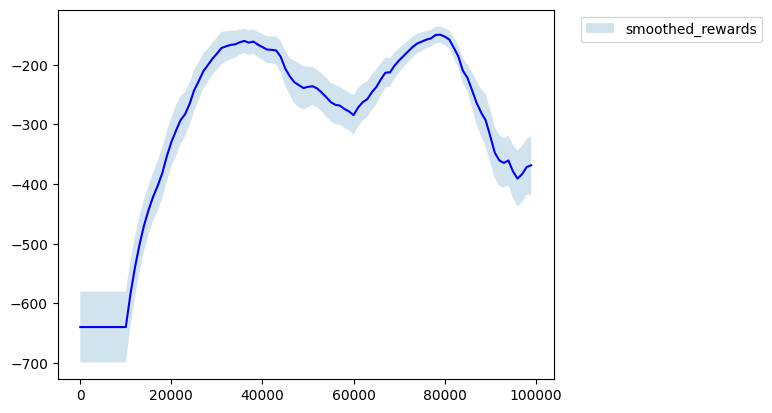

<Figure size 640x480 with 0 Axes>

In [9]:
dqn = DQN(args)
result_means_dqn, result_stds_dqn = train_dqn(dqn)
plot_results(result_means_dqn, result_stds_dqn)

# eps greedy

Here the goal is to implement the epsilon-gredy strategy. With probability epsilon we choose uniformly a random action and with probability 1-epsilon we take the action with the highest Q-value according to the main critic.

In [10]:
class EpsilonGreedyDQN(DQN):
  def __init__(self, args, epsilon=0.1):
    super(EpsilonGreedyDQN, self).__init__(args)
    self.epsilon = epsilon

  def explore(self, states):
    rand = np.random.rand(states.shape[1])
    use_greedy = (rand >= self.epsilon)

    explore_actions = super().explore(states)
    greedy_action = self.get_greedy_action(states.squeeze(0))
    
    actions = np.where(use_greedy, greedy_action, explore_actions)
    return actions

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -89.25600143052391; eval_std: 19.259267685965806
Training step: 12000
Eval mean: -8.157057814709658; 

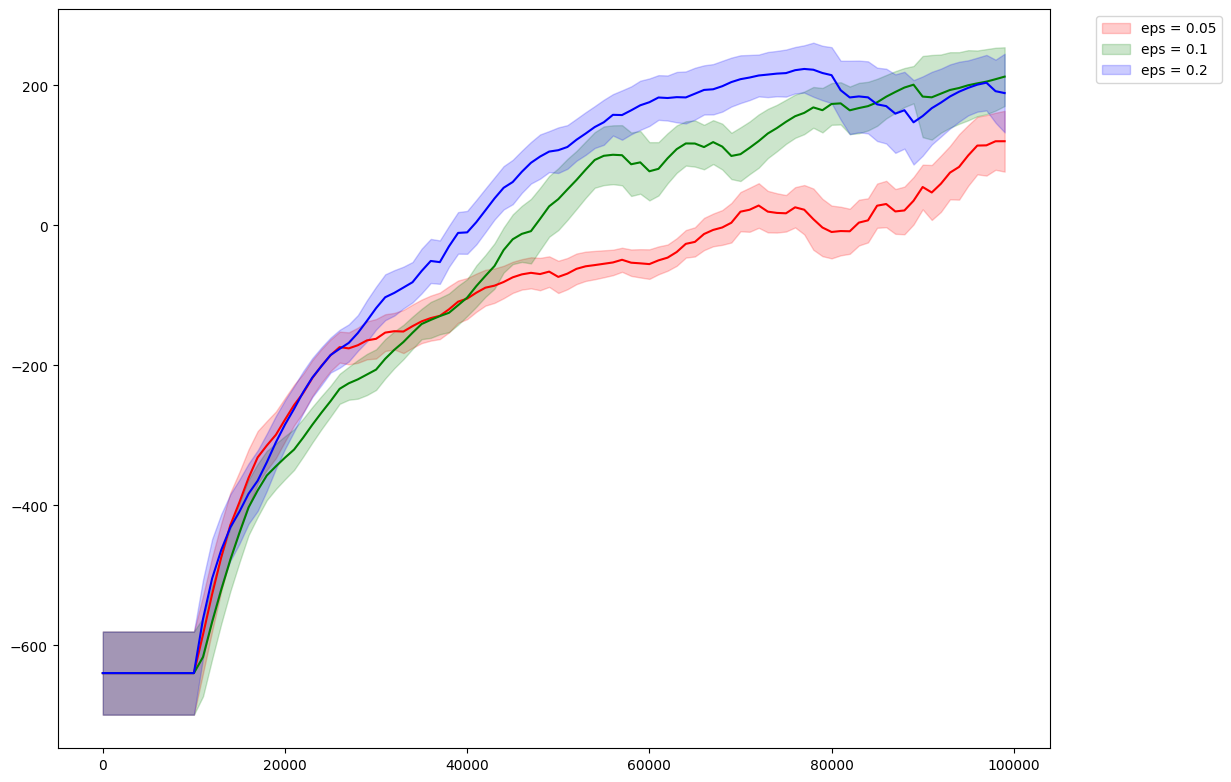

<Figure size 640x480 with 0 Axes>

In [11]:
means_list = []
stds_list = []
names_list = []

for eps in [0.05, 0.1, 0.2]:
    epsilon_greedy_dqn = EpsilonGreedyDQN(args, eps)
    result_means_epsilon_greedy_dqn, result_stds_epsilon_greedy_dqn = train_dqn(epsilon_greedy_dqn)
    means_list.append(result_means_epsilon_greedy_dqn)
    stds_list.append(result_stds_epsilon_greedy_dqn)
    names_list.append("eps = " + str(eps))
plot_results_many(means_list, stds_list, names_list, colours_list[:len(means_list)])
# plot_results(result_means_epsilon_greedy_dqn, result_stds_epsilon_greedy_dqn)

# Eps greedy with annealing

Here we add to the epsilon-greedy strategy epsilon annealing. We change linearly epsilon from 1.0 to the value final_epsilon during first anneal_steps steps and then it remains on the final_epsilon level.
Such an approach aims to increase the exploration level at the beginning of the training, when the Q-value estimate is poor and thus choosing greedily according to Q is not improving the performance.

In [12]:
class EpsilonGreedyWithAnnealingDQN(EpsilonGreedyDQN):
  def __init__(self, args, final_epsilon=0.1):
    self.start_epsilon = 1.0
    super(EpsilonGreedyWithAnnealingDQN, self).__init__(args)
    self.epsilon = self.start_epsilon
    self.final_epsilon = final_epsilon # investigate sensitivity
    self.annealing = True
    self.anneal_steps = 30000

  def anneal(self, step):
    step += 1 # so that on step 0 we actually anneal
    if step >= self.anneal_steps:
      self.epsilon = self.final_epsilon
    else:
      e1 = self.final_epsilon * step / self.anneal_steps
      e2 = self.start_epsilon * (1 - step / self.anneal_steps)
      self.epsilon = e1 + e2

  def reset(self):
    super(EpsilonGreedyWithAnnealingDQN, self).reset()
    self.epsilon = self.start_epsilon

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -109.35281736707115; eval_std: 8.289441805385035
Training step: 12000
Eval mean: -87.79918612925694; 

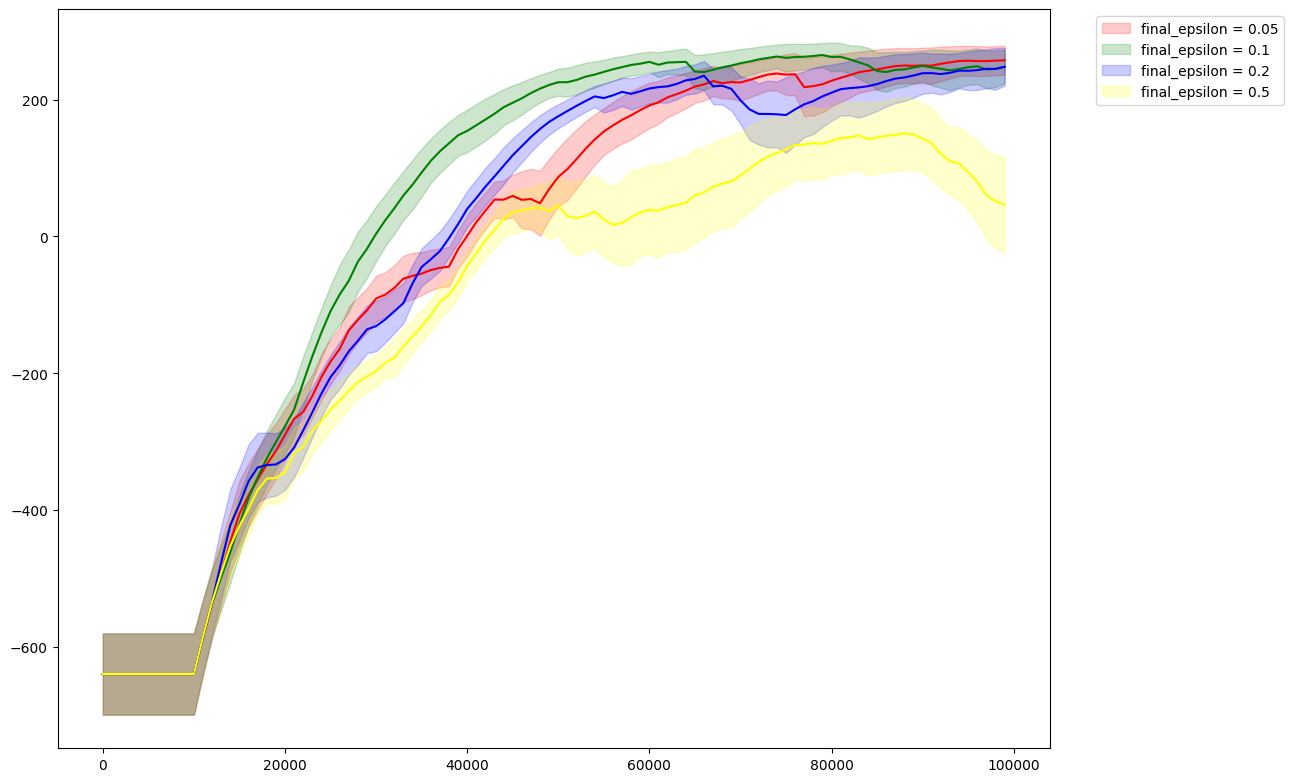

<Figure size 640x480 with 0 Axes>

In [13]:
means_list = []
stds_list = []
names_list = []

for eps in [0.05, 0.1, 0.2, 0.5]:
    epsilon_greedy_with_annealing_dqn = EpsilonGreedyWithAnnealingDQN(args, eps)
    result_means_epsilon_greedy_with_annealing_dqn, result_stds_epsilon_greedy_with_annealing_dqn = train_dqn(epsilon_greedy_with_annealing_dqn)
    means_list.append(result_means_epsilon_greedy_with_annealing_dqn)
    stds_list.append(result_stds_epsilon_greedy_with_annealing_dqn)
    names_list.append("final_epsilon = " + str(eps))

plot_results_many(means_list, stds_list, names_list, colours_list[:len(means_list)])
# plot_results(result_means_epsilon_greedy_with_annealing_dqn, result_stds_epsilon_greedy_with_annealing_dqn)

# Boltzmann

Alternative approach to the epsilon-greedy strategy is to use so-called boltzmann exploration strategy.
The idea behind this approach is to perform softmax on the Q-values coming from the main critic and then sample from the obtained distribution.
In this approach we use softmax with a temperature, i.e. before applying softmax, we scale all the Q-values by the temperature coefficient (in the literature we usually divide by the temperature, but this is equivallent to scaling by the inverse of the temperature). Large scaling values make the distribution close to the greedy choice, while low scaling values make the distribution close to the uniform one.

In [14]:
class BoltzmannDQN(DQN):
  def __init__(self, args, temperature=1.0):
    super(BoltzmannDQN, self).__init__(args)
    self.temperature = temperature # investigate sensitivity

  def explore(self, states):
    action = None
    with torch.no_grad():
      q_values = self.q_net(states)
      logits = q_values * self.temperature
      sm = torch.nn.functional.softmax(logits, dim=-1)
      
      (_, _, action_size) = sm.size()
      action = torch.multinomial(sm.view(-1, action_size), num_samples=1)
      action = action.reshape(-1).detach().cpu().numpy()
    return action

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -78.51123758156028; eval_std: 7.719574871338158
Training step: 12000
Eval mean: -169.5235969298257; e

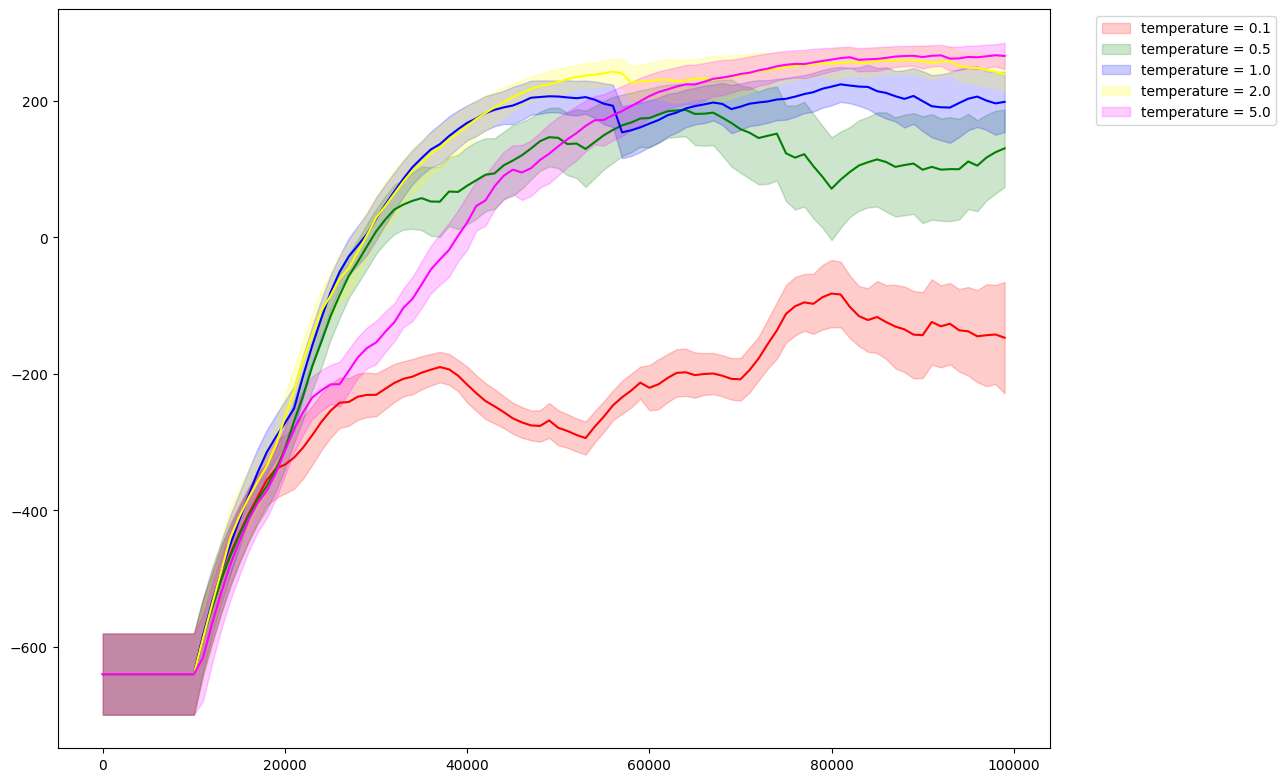

<Figure size 640x480 with 0 Axes>

In [15]:
means_list = []
stds_list = []
names_list = []

for t in [0.1, 0.5, 1.0, 2.0, 5.0]:
    boltzmann_dqn = BoltzmannDQN(args, t)
    result_means_boltzmann_dqn, result_stds_boltzmann_dqn = train_dqn(boltzmann_dqn)
    means_list.append(result_means_boltzmann_dqn)
    stds_list.append(result_stds_boltzmann_dqn)
    names_list.append("temperature = " + str(t))

plot_results_many(means_list, stds_list, names_list, colours_list[:len(means_list)])
# plot_results(result_means_boltzmann_dqn, result_stds_boltzmann_dqn)

# Max-Boltzmann

One of the compromises between epsilon-greedy and boltzmann exploration strategy is so-calles max-boltzmann strategy. In this strategy with probability 1-epsilon we choose action greedily, but with probability epsilon we perform the boltzmann choice instead of the uniform random choice.

In [16]:
class MaxBoltzmannDQN(EpsilonGreedyWithAnnealingDQN):
  def __init__(self, args, temperature=0.1):
    super(MaxBoltzmannDQN, self).__init__(args)
    self.temperature = temperature # investigate sensitivity

  def explore(self, states):
    rand = np.random.rand(states.shape[1])
    use_greedy = (rand >= self.epsilon)
    with torch.no_grad():
        actions_greedy = self.get_greedy_action(states.squeeze(0))

        q_values = self.q_net(states)
        logits = q_values * self.temperature
        sm = torch.nn.functional.softmax(logits, dim=-1)
        (_, _, action_size) = sm.size()
        actions_boltzmann = torch.multinomial(sm.view(-1, action_size), num_samples=1)
        actions_boltzmann = actions_boltzmann.reshape(-1).detach().cpu().numpy()

        actions = np.where(use_greedy, actions_greedy, actions_boltzmann)
    return actions

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -109.03010714165742; eval_std: 6.919850668483929
Training step: 12000
Eval mean: -76.62856816399416; 

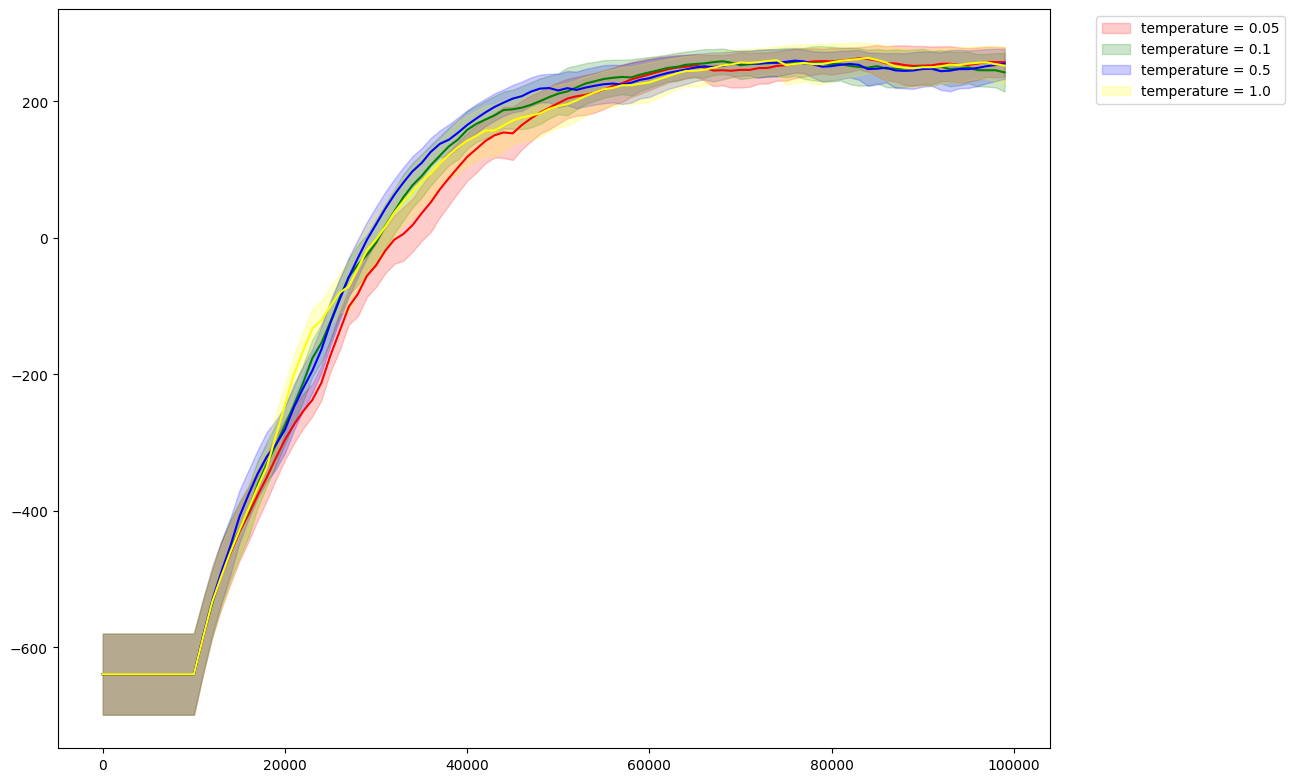

<Figure size 640x480 with 0 Axes>

In [17]:
means_list = []
stds_list = []
names_list = []

for t in [0.05, 0.1, 0.5, 1.0]:
    max_boltzmann_dqn = MaxBoltzmannDQN(args, t)
    result_means_max_boltzmann_dqn, result_stds_max_boltzmann_dqn = train_dqn(max_boltzmann_dqn)
    means_list.append(result_means_max_boltzmann_dqn)
    stds_list.append(result_stds_max_boltzmann_dqn)
    names_list.append("temperature = " + str(t))

plot_results_many(means_list, stds_list, names_list, colours_list[:len(means_list)])
# plot_results(result_means_max_boltzmann_dqn, result_stds_max_boltzmann_dqn)

# Max Boltzmann with annealing

Similarly to adjusting the value of epsilon in epsilon-greedy strategy, we can adjust the temperature in the max-boltzmann and boltzmann strategies: we start we the value start_temperature and linearly increase the value to the final_temperature during temperature_anneal_steps, then the temperature is on the constant level.


In [18]:
class MaxBoltzmannWithTemperatureAnnealingDQN(MaxBoltzmannDQN):
  def __init__(self, args, start_temparature=0.025, final_temperature=0.3):
    self.start_temparature = start_temparature # investigate sensitivity
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).__init__(args)
    self.temperature = self.start_temparature
    self.final_temperature = final_temperature # investigate sensitivity
    self.temperature_anneal_steps = 30000
    self.annealing = True

  def anneal(self, step):
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).anneal(step)
    step += 1 # so that on step 0 we actually anneal
    if step >= self.temperature_anneal_steps:
      self.temperature = self.final_temperature
    else:
      t1 = self.final_temperature * step / self.temperature_anneal_steps
      t2 = self.start_temparature * (1 - step / self.temperature_anneal_steps)
      self.temperature = t1 + t2

  def reset(self):
    super(MaxBoltzmannWithTemperatureAnnealingDQN, self).reset()
    self.temperature = self.start_temparature

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -81.94831862533722; eval_std: 8.772540110981739
Training step: 12000
Eval mean: -46.663303742565574; 

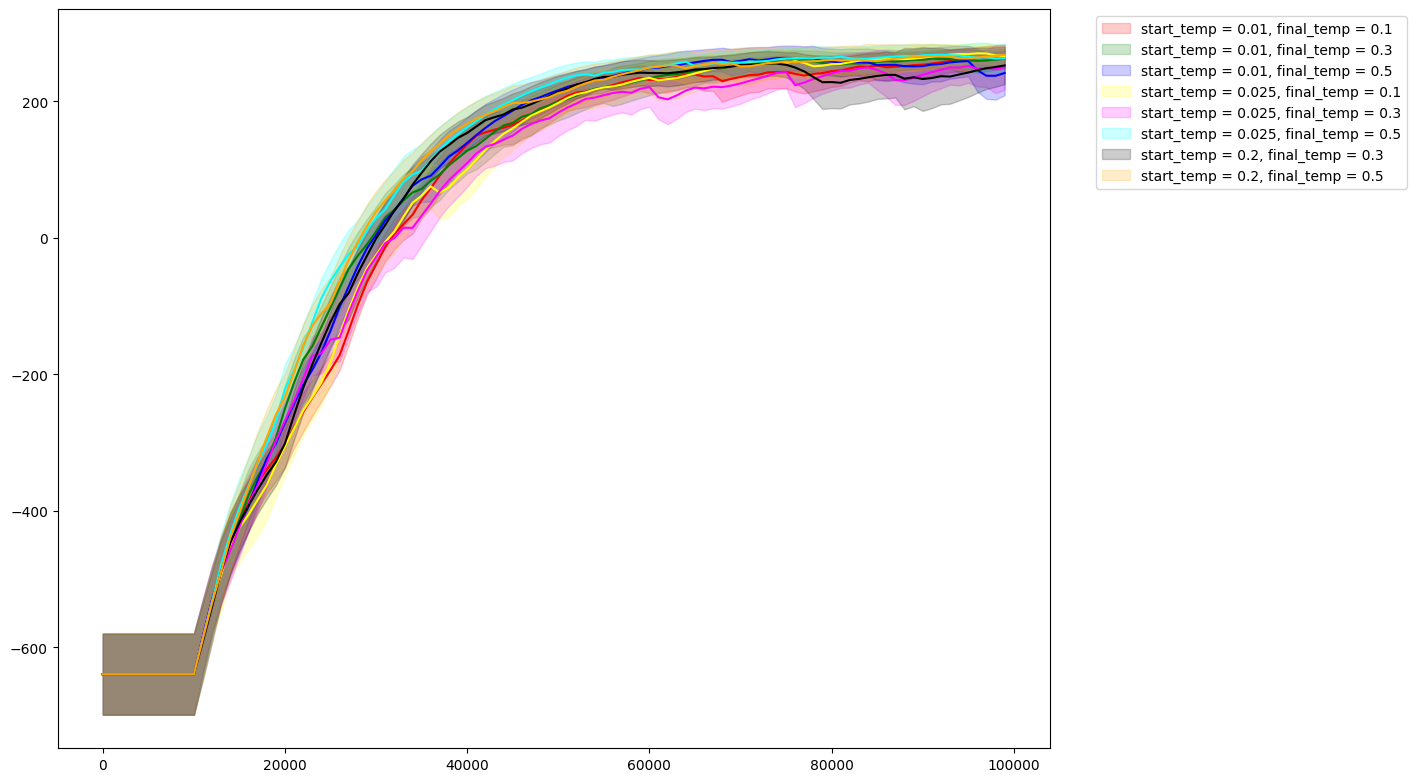

<Figure size 640x480 with 0 Axes>

In [19]:
means_list = []
stds_list = []
names_list = []

for s_t in [0.01, 0.025, 0.2]:
    for f_t in [0.1, 0.3, 0.5]:
        if f_t <= s_t:
            continue
        max_boltzmann_temp_anneal_dqn = MaxBoltzmannWithTemperatureAnnealingDQN(args, s_t, f_t)
        result_means_max_boltzmann_temp_anneal_dqn, result_stds_max_boltzmann_temp_anneal_dqn = train_dqn(max_boltzmann_temp_anneal_dqn)
        means_list.append(result_means_max_boltzmann_temp_anneal_dqn)
        stds_list.append(result_stds_max_boltzmann_temp_anneal_dqn)
        names_list.append("start_temp = " + str(s_t) + ", final_temp = " + str(f_t))
plot_results_many(means_list, stds_list, names_list, colours_list[:len(means_list)])
# plot_results(result_means_max_boltzmann_temp_anneal_dqn, result_stds_max_boltzmann_temp_anneal_dqn)

In [20]:
class BoltzmannWithTemperatureAnnealingDQN(BoltzmannDQN):
  def __init__(self, args, s_t = 0.25, f_t = 3.0):
    self.start_temparature = s_t # investigate sensitivity
    super(BoltzmannWithTemperatureAnnealingDQN, self).__init__(args)
    self.temperature = self.start_temparature
    self.final_temperature = f_t # investigate sensitivity
    self.temperature_anneal_steps = 30000
    self.annealing = True

  def anneal(self, step):
    step += 1 # so that on step 0 we actually anneal
    if step >= self.temperature_anneal_steps:
      self.temperature = self.final_temperature
    else:
      t1 = self.final_temperature * step / self.temperature_anneal_steps
      t2 = self.start_temparature * (1 - step / self.temperature_anneal_steps)
      self.temperature = t1 + t2

  def reset(self):
    super(BoltzmannWithTemperatureAnnealingDQN, self).reset()
    self.temperature = self.start_temparature

Training step: 0
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 1000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 2000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 3000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 4000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 5000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 6000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 7000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 8000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 9000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 10000
Eval mean: -639.6903477514232; eval_std: 59.38467170955477
Training step: 11000
Eval mean: -96.78726878971366; eval_std: 9.383437277180718
Training step: 12000
Eval mean: -81.44855833668542; e

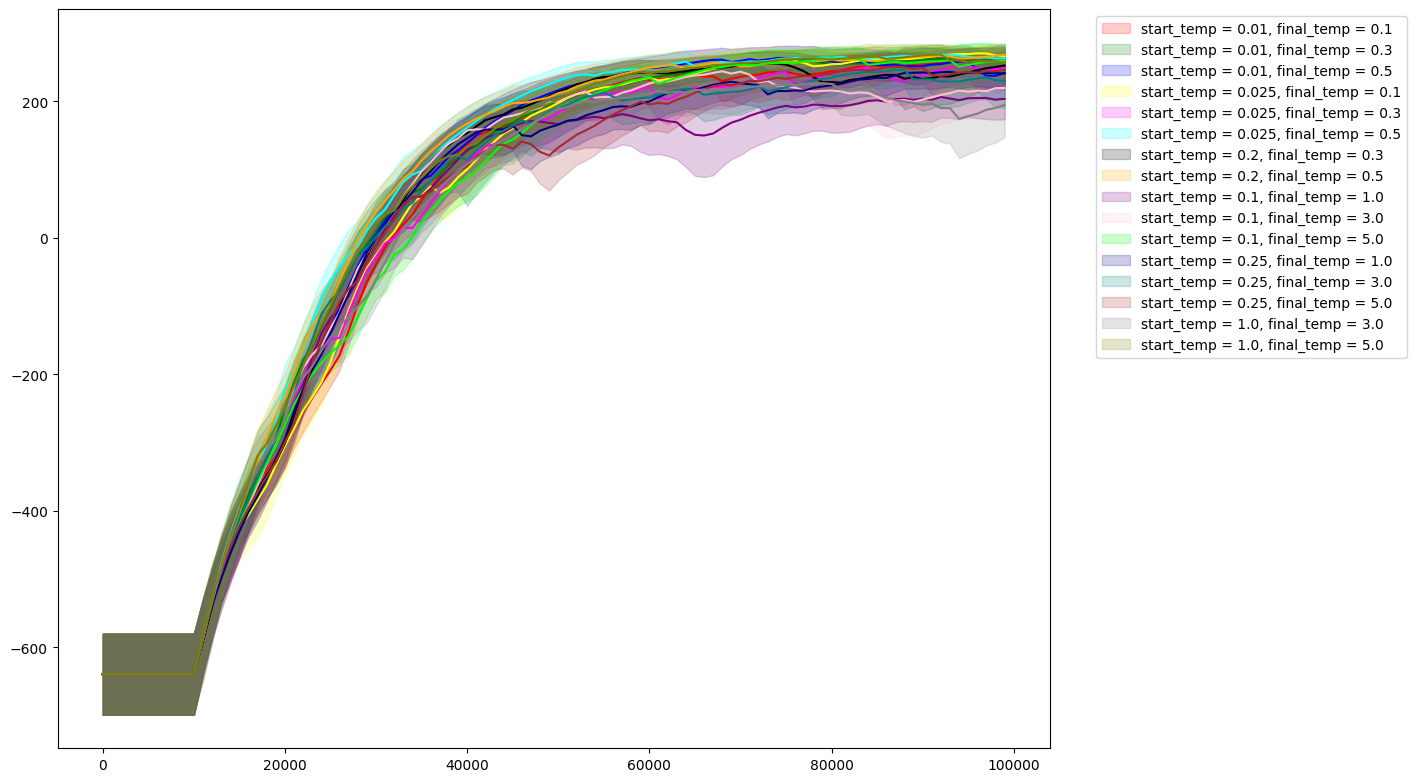

<Figure size 640x480 with 0 Axes>

In [21]:
for s_t in [0.1, 0.25, 1.0]:
    for f_t in [1.0, 3.0, 5.0]:
        if f_t <= s_t:
            continue
        boltzmann_temp_anneal_dqn = BoltzmannWithTemperatureAnnealingDQN(args, s_t, f_t)
        result_means_boltzmann_temp_anneal_dqn, result_stds_boltzmann_temp_anneal_dqn = train_dqn(boltzmann_temp_anneal_dqn)
        means_list.append(result_means_boltzmann_temp_anneal_dqn)
        stds_list.append(result_stds_boltzmann_temp_anneal_dqn)
        names_list.append("start_temp = " + str(s_t) + ", final_temp = " + str(f_t))
plot_results_many(means_list, stds_list, names_list, colours_list[:len(means_list)])
# plot_results(result_means_boltzmann_temp_anneal_dqn, result_stds_boltzmann_temp_anneal_dqn)

The last exploration idea we want to implement is a combintation of the epsilon-greedy strategy (with epsilon annealing) and the boltzmann strategy.
We could think that at the beginning of the training the boltzmann strategy struggles because the Q-function (the main critic) is not yet well-trained. However, the more critic is trained, the more sense it makes to start using the boltzmann strategy. We would like to verif y this hypoothesis by using in the first half of the training epsilon-greedy strategy (with epsilon annealing) and in the second half of the training switch the exploration strategy to the boltzmann one.

In [22]:
def train_two_halfs_dqn(dqn_1, dqn_2):
  set_seed(TRAIN_SEED)
  
  result_mean_1, result_std_1 = dqn_1.train()

  dqn_2.q_net.load_state_dict(dqn_1.q_net.state_dict())
  dqn_2.q_target.load_state_dict(dqn_1.q_target.state_dict())

  result_mean_2, result_std_2 = dqn_2.train()

  result_mean = np.concatenate([result_mean_1, result_mean_2])
  result_std = np.concatenate([result_std_1, result_std_2])

  return result_mean, result_std


Training step: 0
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 1000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 2000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 3000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 4000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 5000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 6000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 7000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 8000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 9000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 10000
Eval mean: -538.2592581746047; eval_std: 55.08221345851011
Training step: 11000
Eval mean: -114.11003578408365; eval_std: 35.00324442432747
Training step: 12000
Eval mean: -69.13980056043562; 

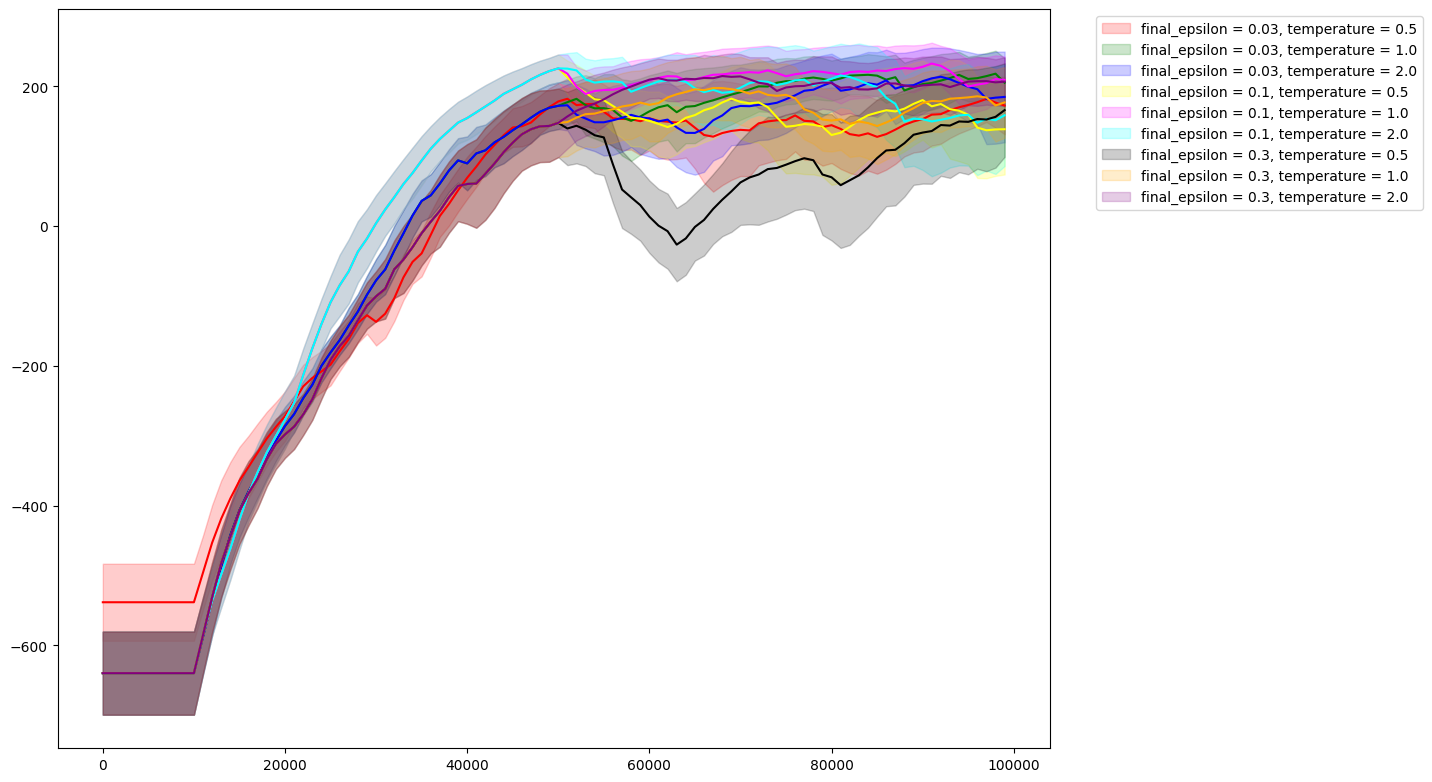

<Figure size 640x480 with 0 Axes>

In [23]:
means_list = []
stds_list = []
names_list = []

for eps in [0.03, 0.1, 0.3]:
    for t in [0.5, 1.0, 2.0]:
        epsilon_greedy_with_annealing_half_dqn = EpsilonGreedyWithAnnealingDQN(first_half_training_args, eps) # investigate sensitivity of epsilon
        epsilon_greedy_boltzmann_half_dqn = BoltzmannDQN(second_half_training_args, t) # investigate sensitivity of temperature
        result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn = train_two_halfs_dqn(epsilon_greedy_with_annealing_half_dqn, epsilon_greedy_boltzmann_half_dqn)
        means_list.append(result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn)
        stds_list.append(result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn)
        names_list.append("final_epsilon = " + str(eps) + ", temperature = " + str(t))
plot_results_many(means_list, stds_list, names_list, colours_list[:len(means_list)])
# plot_results(result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn, result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn)

Here we plot the results of all exploration methods on one plot. However, for drawing conclusions, it might be reasonable to plot some subsets of methods together, for example to compare variants with and without annealing, max-boltzmann with boltzmann, epsilon-greedy, boltzmann and half-epsilon-greedy, half-boltzmann.

[-639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -639.69034775 -639.69034775 -639.69034775 -639.69034775
 -639.69034775 -585.14569421 -540.03990527 -501.74488511 -469.31901932
 -443.2744036  -421.02741294 -402.83078247 -381.73313007 -353.50702805
 -329.51675671 -310.64640434 -292.89253479 -282.88361429 -265.56304788
 -242.69451334 -227.53670297 -210.9790205  -200.55447976 -189.96728148
 -181.21003079 -171.82478178 -169.02009176 -166.50498065 -165.68691672
 -162.21160593 -159.91008472 -162.7849101  -160.98160161 -166.13870887
 -170.171749   -174.34632713 -174.89024645 -175.78374925 -186.29608667
 -206.10176513 -219.2558915  -229.11375745 -234.13441266 -238.84989448
 -236.92020061 -235.83738629 -239.57584954 -246.43504566 -254.20926006
 -262.56352049 -266.94718256 -268.36465223 -274.03404882 -278.02078302
 -284.28509665 -271.6209233  -262.58861949 -257.75261944 -246.1722367
 -237.24383213 -224.32165755 -213.09760355 -212.68179901 -201.26962708
 -192.5

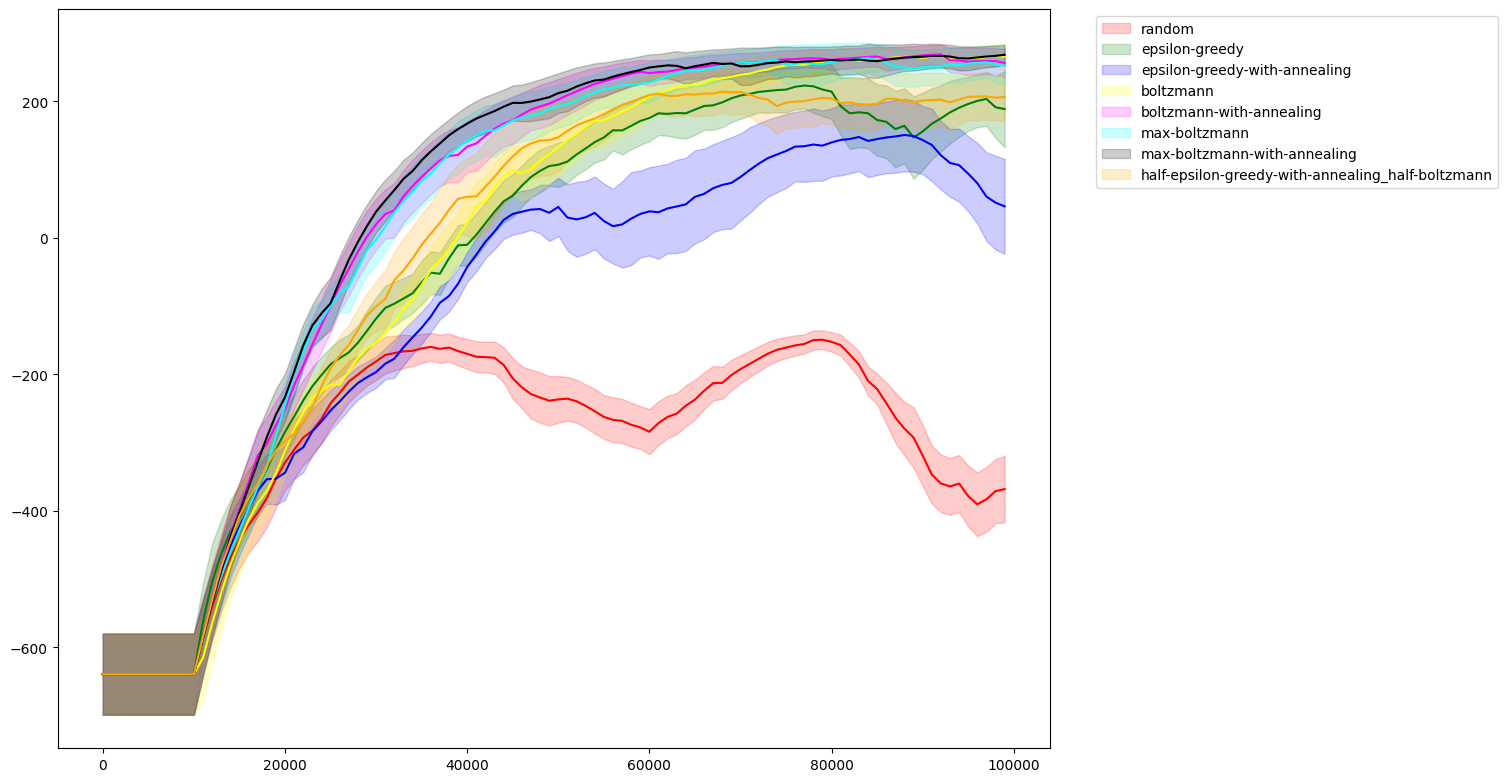

<Figure size 640x480 with 0 Axes>

In [24]:
result_means_list = [result_means_dqn, result_means_epsilon_greedy_dqn, result_means_epsilon_greedy_with_annealing_dqn,
                result_means_boltzmann_dqn, result_means_boltzmann_temp_anneal_dqn,
                result_means_max_boltzmann_dqn, result_means_max_boltzmann_temp_anneal_dqn,
                result_means_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
result_stds_list = [result_stds_dqn, result_stds_epsilon_greedy_dqn, result_stds_epsilon_greedy_with_annealing_dqn,
                result_stds_boltzmann_dqn, result_stds_boltzmann_temp_anneal_dqn,
                result_stds_max_boltzmann_dqn, result_stds_max_boltzmann_temp_anneal_dqn,
                result_stds_epsilon_greedy_with_annealing_half_epsilon_greedy_boltzmann_half_dqn]
names_list = ["random", "epsilon-greedy", "epsilon-greedy-with-annealing",
             "boltzmann", "boltzmann-with-annealing",
             "max-boltzmann", "max-boltzmann-with-annealing",
             "half-epsilon-greedy-with-annealing_half-boltzmann"]
colours_list = ["red", "green", "blue",
           "yellow", "magenta",
           "cyan", "black",
           "orange"]

plot_results_many(result_means_list, result_stds_list, names_list, colours_list)